# 1. Problem Statement

The objective of this project is to develop a predictive analytics model that estimates the future Customer Lifetime Value (CLV) of customers for an e-commerce business. Customer Lifetime Value represents the total revenue a business can expect from a customer throughout their relationship with the company.

Accurately predicting CLV helps businesses identify high-value customers, optimize marketing strategies, improve customer retention, and allocate resources more effectively. By analyzing customer demographics, purchasing behavior, engagement metrics, and transaction history, this project aims to build a regression model capable of predicting each customer's future lifetime value.

The project follows a complete predictive analytics workflow, including exploratory data analysis, data cleaning, feature engineering, model development, evaluation, and business insight generation.

# 2. Dataset Description

The dataset contains customer-level information collected from an e-commerce platform. Each row represents an individual customer and includes demographic details, purchasing behavior, customer engagement metrics, and service-related information.

The dataset consists of 25,625 customer records and 25 features, including the target variable Future_CLV, which represents the predicted future Customer Lifetime Value.

The features can be grouped into the following categories:

Customer Information: Customer ID, Name, Age, Gender, City, State
Membership Information: Membership Level and Acquisition Channel
Purchase Behavior: Total Orders, Total Spend, Average Order Value, Purchase Frequency, Total Items Purchased
Customer Engagement: Website Visits, App Sessions, Days Since Last Purchase
Customer Service: Return Rate, Support Tickets, Customer Satisfaction
Payment Information: Preferred Payment Method
Target Variable: Future_CLV

The objective is to predict the Future_CLV using the remaining customer-related features.

In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [74]:
df = pd.read_csv(r"C:\Users\aswin\OneDrive\Desktop\Predictive-Analytics-Mini-Project\data\ecommerce_clv_dataset.csv")

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
0,CUST100000,Madhuri Gupta,22.0,Female,Kolkata,West Bengal,Silver,Organic Search,331,2,3,1805.18,902.59,Sports & Fitness,37.0,27.0,335.0,0.181,168.73,0.478,0.535,3.0,3.27,Debit Card,200.00
1,CUST100001,Ritu Naidu,34.0,Other,Ahmedabad,Gujarat,Silver,Paid Ads,214,3,7,4518.55,1506.18,Home & Kitchen,31.0,20.0,145.0,0.421,67.69,0.392,0.428,2.0,3.64,Credit Card,325.56
2,CUST100002,Vidya Menon,37.0,Female,Hyderabad,Telangana,Silver,Email Marketing,1890,28,79,15672.76,559.74,Grocery,148.0,125.0,87.0,0.444,62.52,0.342,0.229,2.0,3.67,UPI,1201.04
3,CUST100003,Pankaj Pandey,29.0,Male,Delhi,Delhi,Silver,Organic Search,1170,20,37,14660.69,733.03,Fashion,98.0,61.0,27.0,0.513,68.20,0.278,0.421,4.0,3.34,UPI,747.54
4,CUST100004,Pooja Kumar,20.0,Female,Pune,Maharashtra,Silver,Organic Search,360,1,2,303.17,303.17,Electronics,115.0,92.0,398.0,0.083,323.45,0.112,0.266,4.0,3.94,Cash on Delivery,200.00


In [75]:
df.tail()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
25620,CUST109114,Neha Pandey,27.0,Female,Ahmedabad,Gujarat,Gold,Paid Ads,761,13,33,9256.60,712.05,Electronics,220.0,175.0,9.0,0.512,55.74,0.335,0.226,2.0,4.02,UPI,1341.24
25621,CUST114433,Radhika Thakur,18.0,Female,Bhopal,Madhya Pradesh,Gold,Organic Search,180,3,7,2334.36,778.12,Home & Kitchen,75.0,35.0,74.0,0.500,59.95,0.907,0.194,3.0,4.06,UPI,200.00
25622,CUST108753,Pallavi Pandey,33.0,Female,Hyderabad,Telangana,Silver,Social Media,688,7,17,4247.36,606.77,Fashion,92.0,79.0,75.0,0.305,86.87,0.047,0.463,3.0,3.00,Credit Card,345.93
25623,CUST115547,Arjun Yadav,21.0,Male,Kochi,Kerala,Silver,Social Media,450,2,5,1162.37,581.18,Sports & Fitness,43.0,28.0,269.0,0.133,219.82,0.755,0.388,2.0,3.56,Debit Card,200.00
25624,CUST109372,Karan Bose,36.0,Male,Delhi,Delhi,Silver,Organic Search,578,5,13,2897.36,579.47,Fashion,57.0,42.0,49.0,0.260,137.48,0.582,0.494,1.0,3.14,UPI,284.38


In [76]:
df.sample(5, random_state=42)

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
10297,CUST110297,Manish Singh,37.0,Male,Ahmedabad,Gujarat,Silver,Social Media,819,6,13,3032.30,505.38,Home & Kitchen,79.0,54.0,88.0,0.220,168.88,0.788,0.348,6.0,4.16,UPI,249.93
14045,CUST114045,Siddharth Singh,51.0,Male,Chennai,Tamil Nadu,Platinum,social media,622,15,27,8158.40,543.89,Fashion,55.0,24.0,12.0,0.723,46.71,0.319,0.335,4.0,3.55,UPI,776.97
18337,CUST118337,Anil Verma,44.0,Male,Delhi,Delhi,Silver,Email Marketing,2520,23,44,18427.12,801.18,Beauty & Personal Care,319.0,274.0,160.0,0.274,130.95,0.306,0.191,0.0,4.14,Credit Card,1350.57
22666,CUST122666,Praveen Thakur,27.0,Male,Jaipur,Rajasthan,Platinum,Organic Search,490,7,24,6763.57,966.22,Electronics,96.0,57.0,98.0,0.429,74.26,0.575,0.210,4.0,3.88,Credit Card,798.31
3096,CUST103096,Radhika Bose,42.0,Female,NaN,Maharashtra,Silver,Organic Search,998,3,6,883.11,294.37,Fashion,24.0,15.0,64.0,0.090,283.54,0.520,0.176,0.0,4.24,UPI,200.00


In [77]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 25625
Number of Columns : 25


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25625 entries, 0 to 25624
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   25625 non-null  str    
 1   Customer_Name                 25590 non-null  str    
 2   Age                           25591 non-null  float64
 3   Gender                        25584 non-null  str    
 4   City                          25583 non-null  str    
 5   State                         25598 non-null  str    
 6   Membership_Level              25589 non-null  str    
 7   Acquisition_Channel           25589 non-null  str    
 8   Customer_Tenure_Days          25625 non-null  int64  
 9   Total_Orders                  25625 non-null  int64  
 10  Total_Items_Purchased         25625 non-null  int64  
 11  Total_Spend                   25625 non-null  float64
 12  Average_Order_Value           25625 non-null  float64
 13  Preferred_Ca

In [79]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Customer_Tenure_Days', 'Total_Orders', 'Total_Items_Purchased', 'Total_Spend', 'Average_Order_Value', 'Website_Visits', 'App_Sessions', 'Days_Since_Last_Purchase', 'Purchase_Frequency_Per_Month', 'Average_Days_Between_Orders', 'Coupon_Usage_Rate', 'Return_Rate', 'Support_Tickets', 'Customer_Satisfaction', 'Future_CLV']

Categorical Features:
['Customer_ID', 'Customer_Name', 'Gender', 'City', 'State', 'Membership_Level', 'Acquisition_Channel', 'Preferred_Category', 'Preferred_Payment_Method']


In [80]:
missing_values = df.isnull().sum()

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Percentage": (missing_values / len(df)) * 100
    })
    .sort_values(by="Missing Values", ascending=False)
)

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
Average_Days_Between_Orders,53,0.206829
Purchase_Frequency_Per_Month,43,0.167805
City,42,0.163902
Gender,41,0.160000
Return_Rate,39,0.152195
Membership_Level,36,0.140488
Acquisition_Channel,36,0.140488
Days_Since_Last_Purchase,35,0.136585
Customer_Name,35,0.136585
Preferred_Category,35,0.136585


In [81]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 625


In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25591.0,32.657419,9.919393,15.00,26.000,32.0000,38.000,79.000
Customer_Tenure_Days,25625.0,966.680702,587.935012,15.00,524.000,900.0000,1350.000,3650.000
Total_Orders,25625.0,13.876722,14.216044,1.00,4.000,9.0000,19.000,155.000
Total_Items_Purchased,25625.0,31.771317,34.581599,1.00,9.000,21.0000,42.000,445.000
Total_Spend,25625.0,10452.529959,14897.566977,251.29,2237.180,5689.9300,12828.540,453410.700
Average_Order_Value,25625.0,700.125145,365.739038,213.59,444.260,616.8100,858.540,5333.230
Website_Visits,25593.0,139.557105,134.726458,2.00,50.000,99.0000,183.000,1722.000
App_Sessions,25601.0,90.651225,91.605669,1.00,31.000,63.0000,118.000,1410.000
Days_Since_Last_Purchase,25590.0,149.947987,188.312571,0.00,32.000,78.0000,182.000,900.000
Purchase_Frequency_Per_Month,25582.0,0.425699,0.300280,0.02,0.205,0.3525,0.564,3.228


In [83]:
df.describe(include='str').T

,count,unique,top,freq
Customer_ID,25625,25000,CUST100127,2
Customer_Name,25590,1800,Praveen Gupta,31
Gender,25584,14,Male,12883
City,25583,96,Delhi,2102
State,25598,58,Maharashtra,3317
Membership_Level,25589,18,Silver,12761
Acquisition_Channel,25589,38,Organic Search,6843
Preferred_Category,25590,43,Electronics,5607
Preferred_Payment_Method,25591,30,UPI,10409


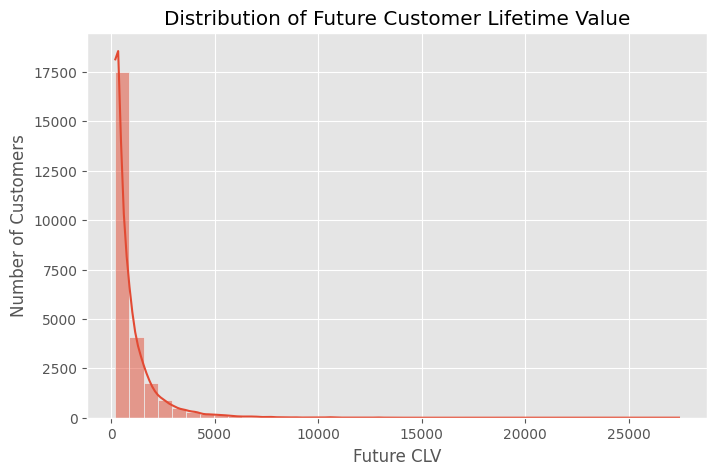

In [95]:
plt.figure(figsize=(8,5))

sns.histplot(df["Future_CLV"], bins=40, kde=True)

plt.title("Distribution of Future Customer Lifetime Value")
plt.xlabel("Future CLV")
plt.ylabel("Number of Customers")

plt.show()

The distribution of Future_CLV is highly right-skewed. Most customers have relatively low lifetime values, while a small number of customers contribute exceptionally high lifetime value. This pattern is common in e-commerce datasets, where a small proportion of loyal customers generate a significant share of total revenue.

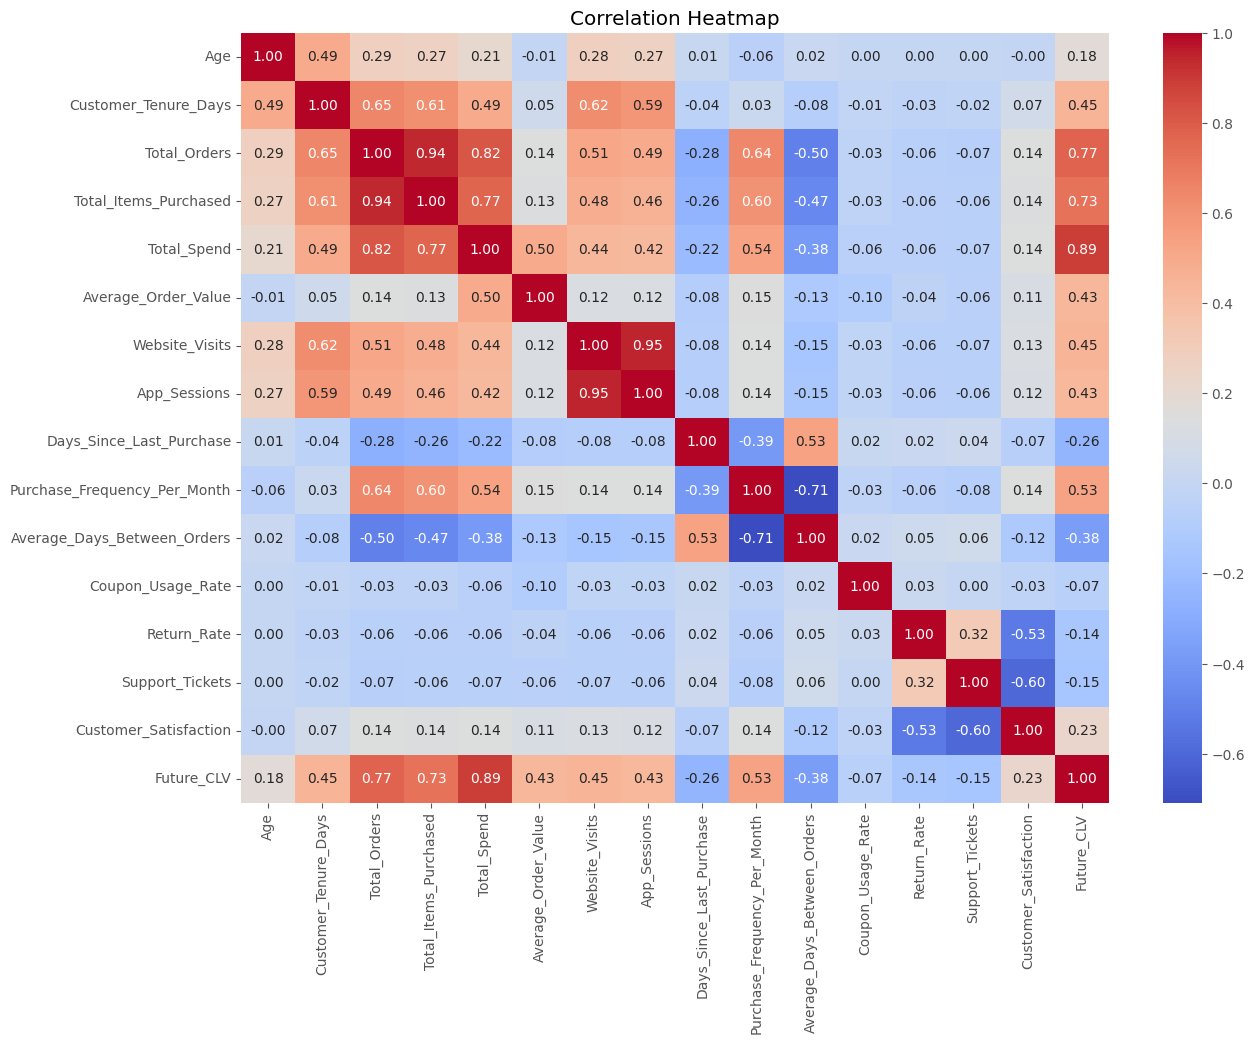

In [90]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation analysis indicates that Total Spend, Total Orders, and Total Items Purchased have strong positive relationships with Future_CLV, suggesting that customers with higher purchasing activity tend to generate greater lifetime value. Conversely, longer intervals between purchases and a greater number of days since the last purchase are negatively associated with Future_CLV.

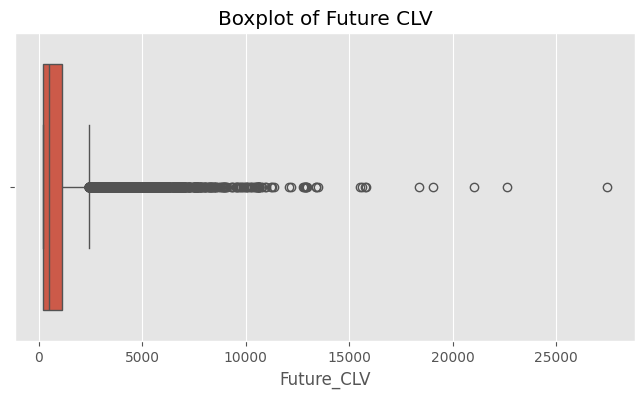

In [86]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Future_CLV"])

plt.title("Boxplot of Future CLV")

plt.show()

The boxplot reveals several high-value observations in the Future_CLV variable. These likely represent premium or highly loyal customers rather than data entry errors. Since such customers naturally exist in e-commerce businesses, these observations will not be removed unless further analysis identifies them as invalid.

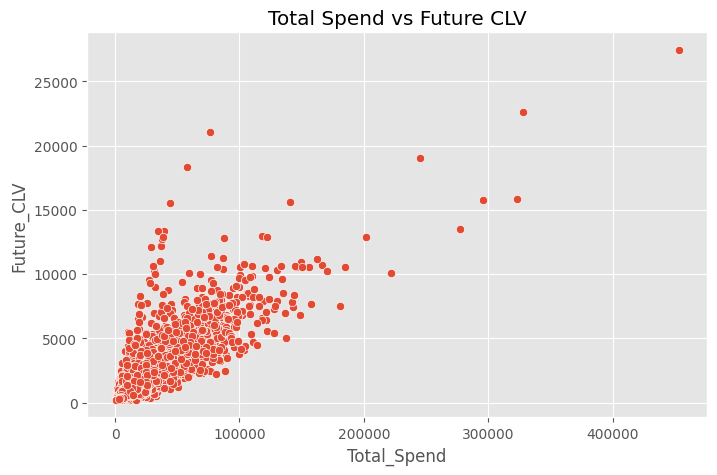

In [87]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Total_Spend",
    y="Future_CLV"
)

plt.title("Total Spend vs Future CLV")

plt.show()

The scatter plot demonstrates a clear positive relationship between Total Spend and Future_CLV. Customers with higher historical spending generally exhibit higher predicted lifetime value, making Total Spend a potentially important predictor during model development.

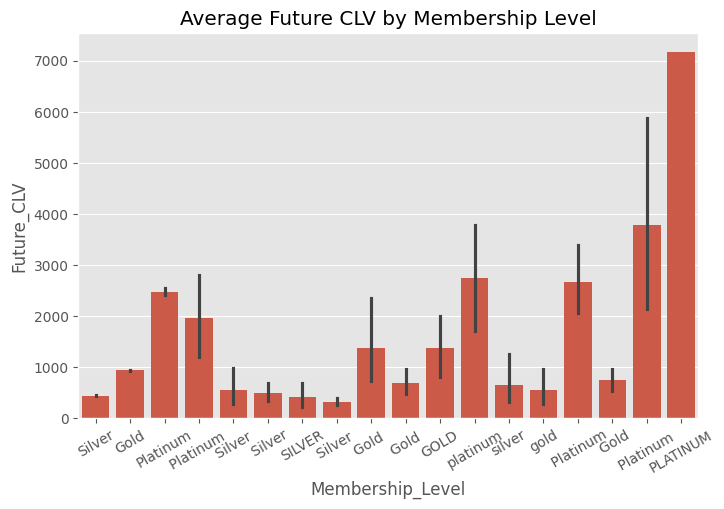

In [93]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Membership_Level",
    y="Future_CLV",
    estimator=np.mean
)

plt.title("Average Future CLV by Membership Level")

plt.xticks(rotation=30)

plt.show()

The average Future_CLV differs across membership levels. The presence of repeated membership categories with different letter cases indicates inconsistent categorical values in the raw dataset. These inconsistencies will be corrected during the data cleaning phase before model development.

# Key Findings from Exploratory Data Analysis
1. The dataset contains 25,625 customer records and 25 features.
2. Both numerical and categorical variables are present.
3. Missing values exist in multiple columns but account for a very small percentage of the dataset.
4. A total of 625 duplicate records were identified.
5. The target variable, Future_CLV, exhibits a right-skewed distribution with a small number of high-value customers.
6. Purchasing behavior features such as Total Spend, Total Orders, and Total Items Purchased show strong positive correlations with Future_CLV.
7. Inconsistent categorical values are visible in certain columns, indicating that data cleaning is necessary before modeling.